In [1]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_160226_t1_t2.csv'

# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

#### computing differences

TA1, TG1: Air temperature and Globe temperature - thermometer 1 (Sper Scientific 800036)

TA2, TG2: Air temperature and Globe temperature - thermometer 2 (TM-188D TENMARS )

ANEMOMETRO: wind speed in km/h with cup anemometer

CONDICION CIELO: sky condition

In [3]:
df = pd.read_csv(ground_data_path, sep=";")
df

,HORA,TA1,TG1,TA2,TG2,ANEMOMETRO,CONDICION CIELO
0,16:28,"26,3","29,6","26,2","29,6",0,RESOLANA SUAVE
1,16:30,"26,3","32,8","26,2","31,1",0,SOL
2,16:32,"25,8","29,5","25,7","28,4",0,RESOLANA SUAVE
3,16:36,26,"28,9","25,8","27,5",0,RESOLANA SUAVE
4,16:39,"26,3","29,8",26,"28,3",0,RESOLANA FUERTE
5,16:42,"27,4","34,8","27,9","31,6","0,7",RESOLANA MUY FUERTE
6,16:43,"27,4","37,4","27,9","32,4","3,9",SOL
7,16:44,"29,2","43,8","29,5","37,3",0,SOL
8,16:50,"27,1","31,2","26,9","28,9",0,RESOLANA SUAVE
9,16:53,"26,4","30,9","25,9","28,3",0,RESOLANA SUAVE


In [4]:
# convert to numeric

cols = ["TG1", "TG2", "TA1", "TA2", "ANEMOMETRO"]

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda x: x.str.replace(",", ".", regex=False))
    .apply(pd.to_numeric, errors="coerce")
)

# TG difference
df["dTG"] = df["TG1"] - df["TG2"]

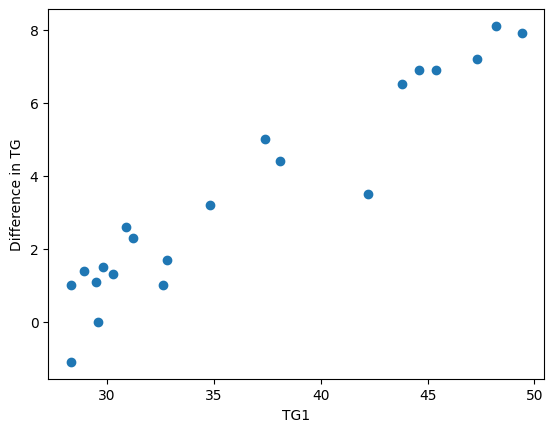

In [5]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1"], df["dTG"])
plt.xlabel("TG1")
plt.ylabel("Difference in TG")
plt.show()

In [6]:
# fitting linear regression to correct TG1 based on TG2

X = df[["TG1"]]
y = df["TG2"]

# Fit 
model = LinearRegression()
model.fit(X, y)

# Coefficients
a = model.coef_[0]
b = model.intercept_

print("Applied correction:")
print(f"TG1_corrected = {a:.3f} * TG1 + {b:.3f}")

# Apply correction: "pass" TG1 to TG2-equivalent
df["TG1_corr"] = a * df["TG1"] + b
df["dTG_CORR"] = df["TG1_corr"] - df["TG2"]

reduction_rmse = (
    1 - np.sqrt((df["dTG_CORR"]**2).mean()) /
        np.sqrt((df["dTG"]**2).mean())
) * 100

print(f"RMSE reduction: {reduction_rmse:.1f} %")


Applied correction:
TG1_corrected = 0.639 * TG1 + 9.681
RMSE reduction: 81.4 %


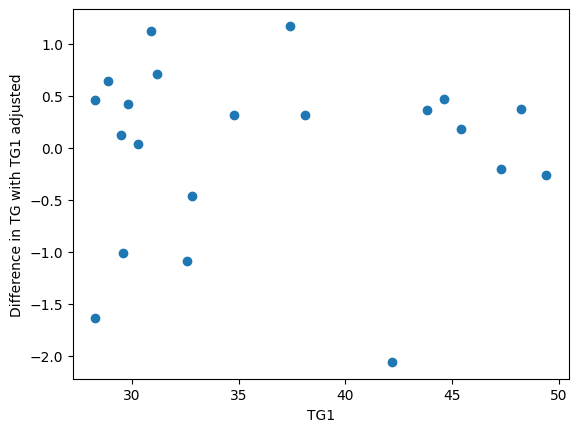

In [7]:
# Scatter: TG1 vs dTG
plt.scatter(df["TG1"], df["dTG_CORR"])
plt.xlabel("TG1")
plt.ylabel("Difference in TG with TG1 adjusted")
plt.show()

In [8]:
metrics = pd.DataFrame({
    "metric": ["mean", "std", "RMSE", "MAE"],
    "dTG_raw": [
        df["dTG"].mean(),
        df["dTG"].std(),
        np.sqrt((df["dTG"]**2).mean()),
        df["dTG"].abs().mean()
    ],
    "dTG_corr": [
        df["dTG_CORR"].mean(),
        df["dTG_CORR"].std(),
        np.sqrt((df["dTG_CORR"]**2).mean()),
        df["dTG_CORR"].abs().mean()
    ]
})

print(metrics)


  metric   dTG_raw      dTG_corr
0   mean  3.447619  6.767074e-15
1    std  2.826945  8.414298e-01
2   RMSE  4.415557  8.211514e-01
3    MAE  3.552381  6.405925e-01


C:\Users\guada\AppData\Local\Temp\ipykernel_13768\3944679771.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


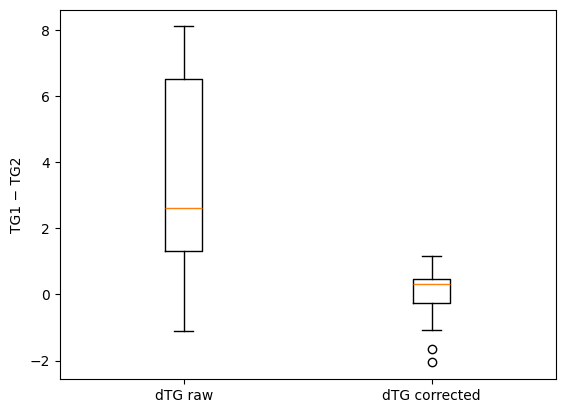

In [9]:
plt.boxplot(
    [df["dTG"].dropna(), df["dTG_CORR"].dropna()],
    labels=["dTG raw", "dTG corrected"]
)
plt.ylabel("TG1 − TG2")
plt.show()
